In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px 

from sklearn.preprocessing import StandardScaler

from non_parametric_pro.density import ProParameters, pro_logdensity_fn
from non_parametric_pro.sgld import parametric_sgld, sgld
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, run_inference_algorithm_with_burn_in
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.inducing import PointInducingBasis, compute_inducing_basis, kmeans_inducing_points, RFFInducingBasis, sample_rff_frequencies
from non_parametric_pro.adaptation.parameter_adaptation import cross_validated_parameter_adaptation

jax.config.update("jax_enable_x64", True)

In [42]:
dataset_name = "airfoil"
split = 2

num_inducing_points = 200

In [43]:
key = jr.PRNGKey(0)

example = load_uci_regression_dataset(dataset_name, split=split)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = jnp.array(scaler_x.fit_transform(example.x_train))
y_train = jnp.array(scaler_y.fit_transform(example.y_train))

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

In [44]:
D = x_train.shape[1]
N = x_train.shape[0]

data = gpx.Dataset(X=x_train, y=y_train)
lengthscale = gpx.parameters.SigmoidBounded(
    jnp.sqrt(D) * jnp.ones((D,)), low=1e-3, high=1e3
)
kernel = gpx.kernels.RBF(lengthscale=lengthscale, variance=px.NonTrainable(jnp.array(1.0)))
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n, obs_stddev=jnp.sqrt(0.01))
posterior = prior * likelihood

z_init = kmeans_inducing_points(key, x_train, num_inducing_points).z 

variational_family = gpx.variational_families.CollapsedVariationalGaussian(
    posterior=posterior,
    inducing_inputs=z_init,
)

opt_variational_family, _ = gpx.fit_scipy(
    model=variational_family,
    objective=lambda p, d: -gpx.objectives.collapsed_elbo(p, d),
    train_data=data,
    verbose=False,
)

vgp_posterior = opt_variational_family.posterior

In [45]:
vgp_latent_dist = opt_variational_family.predict(x_test, train_data=data)
vgp_predictive_dist = vgp_posterior.likelihood(vgp_latent_dist)

vgp_predictive_mean = vgp_predictive_dist.mean
vgp_predictive_std = jnp.sqrt(vgp_predictive_dist.variance)

vgp_sigma = vgp_posterior.likelihood.obs_stddev
vgp_kernel = vgp_posterior.prior.kernel

z_opt = px.unwrap(opt_variational_family.inducing_inputs)

print("VGP NLPD:", nlpd_gp(y_test, vgp_predictive_mean, vgp_predictive_std))

VGP NLPD: 0.13956587808123996


In [46]:
sigma_min = 0.01
pro_kernel = vgp_kernel
pro_sigma = gpx.parameters.SigmoidBounded(px.unwrap(vgp_sigma), low=sigma_min, high=100.0)

J = 20
num_steps = 30000
batch_size = 256

In [47]:
rff_basis = False

if rff_basis:
    M = 50
    freqs = sample_rff_frequencies(key, vgp_kernel, num_basis_fns=M)
    inducing_basis = RFFInducingBasis(frequencies=freqs)
else:
    inducing_basis = PointInducingBasis(z=z_opt)

initial_position = jr.normal(key, (inducing_basis.output_dim(), J))

pro_params = ProParameters(
    y=y_train,
    step_size=1e-4,
    sigma=pro_sigma,
    alpha=1.0,
)

sgld_algo = sgld(batch_size=batch_size)

In [48]:
adaptation = cross_validated_parameter_adaptation(
    sgld_algo,
    pro_logdensity_fn,
    pro_params,
    x_full=x_train,
    y_full=y_train,
    initial_kernel=pro_kernel,
    num_folds=1,
    val_fraction=0.2,
    num_particles=J,
    num_steps=10000,
    warmup_steps=1000,
    sigma_adapt_every=10,
    kernel_adapt_every=-1,
    objective_fn=pro_logdensity_fn,
    sigma_optimizer=ox.adam(1e-1),
    kernel_optimizer=ox.adam(1e-2),
    progress_bar=True,
    rng_key=key,
    inducing_basis=inducing_basis,
)

adapt_params = pro_params._replace(sigma=adaptation.sigma)
adapt_kernel = adaptation.kernel
basis, residual_std = compute_inducing_basis(inducing_basis, adapt_kernel, x_train, jitter=1e-6)
adapt_params = adapt_params._replace(basis=basis, residual_std=residual_std)

Running parameter adaptation


<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

Burning in for 13500 steps...


<div><progress max="13500" value="13500"></progress> 100.00% [13500/13500 00:00&lt;?]</div>

Sampling for 1500 steps...


<div><progress max="1500" value="1500"></progress> 100.00% [1500/1500 00:00&lt;?]</div>

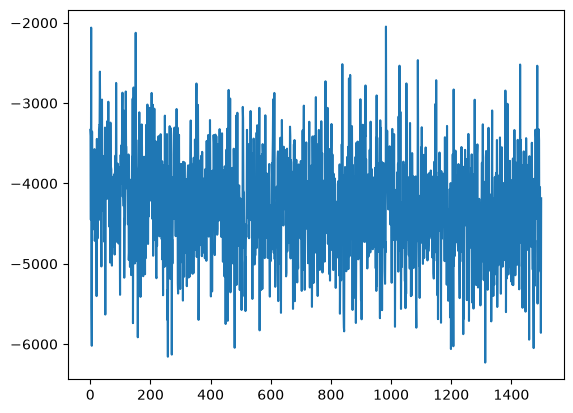

In [49]:
algorithm = parametric_sgld(pro_logdensity_fn, adapt_params, batch_size=batch_size)
initial_position = jr.normal(key, (inducing_basis.output_dim(), J))

_, (states, info) = run_inference_algorithm_with_burn_in(
    rng_key=key,
    inference_algorithm=algorithm,
    num_steps=15000,
    burn_ratio=0.9,
    initial_position=initial_position,
    progress_bar=True
)

plt.plot(-info.score)
plt.show()

In [50]:
thin = 10
particles = states.position[::thin]

In [51]:
test_basis, test_cov = prediction_basis(pro_kernel, x_train, x_train, adapt_params, inducing_basis=inducing_basis)

vgp_latent_dist = vgp_posterior.predict(x_train, train_data=data)
vgp_predictive_dist = vgp_posterior.likelihood(vgp_latent_dist)

vgp_predictive_mean = vgp_predictive_dist.mean
vgp_predictive_std = jnp.sqrt(vgp_predictive_dist.variance)

print("PRO NLPD:", nlpd_pro(y_train, test_basis, test_cov, particles, parameters=adapt_params))
print("VGP NLPD:", nlpd_gp(y_train, vgp_predictive_mean, vgp_predictive_std))

PRO NLPD: -0.18109350969060178
VGP NLPD: -0.02479659774939894


In [52]:
test_basis, test_cov = prediction_basis(pro_kernel, x_train, x_test, adapt_params, inducing_basis=inducing_basis)

vgp_latent_dist = vgp_posterior.predict(x_test, train_data=data)
vgp_predictive_dist = vgp_posterior.likelihood(vgp_latent_dist)

vgp_predictive_mean = vgp_predictive_dist.mean
vgp_predictive_std = jnp.sqrt(vgp_predictive_dist.variance)

print("PRO NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=adapt_params))
print("VGP NLPD:", nlpd_gp(y_test, vgp_predictive_mean, vgp_predictive_std))

PRO NLPD: -0.013546912845520278
VGP NLPD: 0.12265300721009526
